# Module 10 — Metric-Movement Diagnosis

Part of the Product Analytics Playbook. Program and progress: [CURRICULUM.md](CURRICULUM.md).

## Why you're here: what this module is for

- "Metric X dropped, why?" comes up in almost every product-analyst interview and in real jobs every week.
- A good answer follows a fixed order of checks, so the cheap, common causes (a logging bug, the calendar) are ruled out before anyone hunts for a change in user behaviour.
- This module sets out that order, applies it to real movements in the store's data and to one simulated case with a planted logging bug, and writes each answer as a short memo.

**What this module produces:**
1. The checklist, and the rate-vs-mix split it uses.
2. Three worked cases: one where the answer is "we can't tell from this data", one split into rate and mix, and one where the cause is a logging bug.
3. Two diagnosis memos as exercises.

## From the curriculum

> ## <u>Module 10 — Metric-Movement Diagnosis</u>
>
> **Added beyond the original scope:** it is a top product-analyst interview
> question, it uses Modules 1–9 together, and no earlier repo covers it.
>
> **Concepts**
> - A fixed order of checks: is the data right (instrumentation, Module 1), is it the
>   calendar, is it mix or rate, where is it (segment, funnel step)
> - Rate-vs-mix decomposition: splitting a change into "groups changed size"
>   and "groups changed behaviour"
> - When a movement can't be explained by this data, saying so
>
> **Why it matters**
> "Metric X dropped 8% yesterday, why?" is asked in nearly every product-analyst
> interview and in real jobs every week. A structured answer that checks the logging
> first saves days of chasing a bug as if it were user behaviour.
>
> **Worked example**
> A real movement in the running dataset, worked through the checklist (first
> case: the February 2020 surge in zero-price cart events found in Module 1),
> plus a simulated case with a planted logging bug as known ground truth.
>
> **Resources**
> - [Simpson's paradox](https://en.wikipedia.org/wiki/Simpson%27s_paradox)
>   (Wikipedia, verified): the extreme case of mix vs. rate, where a trend in
>   every group reverses once the groups are combined.
>
> **Exercise type:** fully worked diagnosis memos.
>
> **Interview angle:** "DAU dropped 8% last Tuesday. Walk me through it."

## Lesson

### The checklist, in order

1. **Is the data right?** Check the logging first (Module 1): did an event stop or start being sent, did a field go empty, does a second source agree?
2. **Is it the calendar?** Compare like with like: month length (Module 6), weekday, holidays.
3. **Mix or rate?** Did the groups' shares of users change, or did the groups change behaviour? (Below.)
4. **Where is it?** Find the segment or funnel step where the change sits.
5. **Say what the data can't explain.** A diagnosis can end at "not explained by this data", with what would settle it.

The order matters: each step is cheaper than the next, and a logging bug found at step 1 saves days of studying user behaviour that never changed.

### Rate vs. mix, step by step

A rate for all users (e.g. the payer rate) is built from groups (e.g. new and returning users):

1. Overall rate = for each group, its share of users × its rate, added up.
2. Between two periods, both the shares and the rates can change.
3. **Mix effect** = for each group, the change in its share × the average of its two rates, added up: the change if only the shares had moved.
4. **Rate effect** = for each group, the average of its two shares × the change in its rate, added up: the change if only behaviour had moved.
5. Mix effect + rate effect = the total change, exactly (Case 2 prints the check in numbers).

### The memo

Each answer is written as a memo, bottom line first:
- **Bottom line:** the answer in one or two sentences.
- **Checks:** the checklist steps, one line each.
- **Not explained:** what this data can't tell, and what other data would tell it.

### Before the cases — What the data can and can't measure

- **No platform, app version, country or marketing channel is logged** (Module 9), so a case where those fields matter has to be simulated (Case 3, labelled as such).
- **No second source:** the store's log is the only record, so "does another source agree?" can't be checked on the real data.
- **"New" users are users whose first event in the data falls in that month.** The data starts in October 2019, so "new" only means "not seen since October 2019" (Module 2). For the same reason, the share of returning users grows each month partly because each month has more earlier months to look back on.
- **Months differ in length** (Module 6), and November holds Black Friday (Module 2).

### Case 1 — Zero-price cart adds jumped in February

**The question:** cart adds with a price of 0 (Module 1) jumped in February 2020. Why?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common import connect, query, metric, show, BLUE, ORANGE, AQUA, GREY

con = connect()
zm = query(con, "SELECT event_month, SUM(price = 0) AS zero, COUNT(*) AS carts, COUNT(DISTINCT CASE WHEN price = 0 THEN user_id END) AS zero_users, COUNT(DISTINCT user_id) AS cart_users FROM events_clean WHERE event_type = 'cart' GROUP BY event_month")
zm["zero %"] = zm["zero"] / zm["carts"] * 100
show(pd.DataFrame({"month": zm["event_month"], "zero-price cart adds": zm["zero"].map("{:,}".format),
                   "all cart adds": zm["carts"].map("{:,}".format), "zero-price %": zm["zero %"].map("{:.2f}".format),
                   "users with zero-price adds": zm["zero_users"].map("{:,}".format), "users with cart adds": zm["cart_users"].map("{:,}".format),
                   "zero-price % ": (zm["zero_users"] / zm["cart_users"] * 100).map("{:.2f}".format)}))
print()
print("zero-price cart adds per user with any: " + ",  ".join(f"{m}: {a / u:.2f}" for m, a, u in zip(zm["event_month"], zm["zero"], zm["zero_users"])))

month    zero-price cart adds  all cart adds  zero-price %  users with zero-price adds  users with cart adds  zero-price %
2019-10                    70        117,556          0.06                          29                13,452           0.22
2019-11                   310        127,142          0.24                          98                 9,512           1.03
2019-12                   122         88,835          0.14                          41                 8,346           0.49
2020-01                   154        110,052          0.14                          73                 9,249           0.79
2020-02                 2,227        108,319          2.06                         144                 8,836           1.63

zero-price cart adds per user with any: 2019-10: 2.41,  2019-11: 3.16,  2019-12: 2.98,  2020-01: 2.11,  2020-02: 15.47


**1. Is the data right?** Each check below asks whether these look like real shoppers adding real products, or like broken or unusual records:

In [2]:
feb = query(con, "SELECT event_date, event_type, product_id, user_id, user_session, price, brand IS NULL AS no_brand FROM events_clean WHERE event_month = '2020-02'")
z = feb[(feb["price"] == 0) & (feb["event_type"] == "cart")]
nz = feb[(feb["price"] > 0) & (feb["event_type"] == "cart")]
print(f"zero-price cart adds: {len(z):,};  users: {z['user_id'].nunique()};  sessions: {z['user_session'].nunique()};  products: {z['product_id'].nunique():,}")
top5 = z["user_id"].value_counts().head(5).sum()
first3 = z["event_date"].isin(["2020-02-01", "2020-02-02", "2020-02-03"]).sum()
print(f"made by the top 5 users: {top5:,} ({top5 / len(z):.2%});  on 1-3 February: {first3:,} ({first3 / len(z):.2%})")
print(f"brand missing: zero-price cart adds {z['no_brand'].mean():.2%}, other cart adds {nz['no_brand'].mean():.2%}")
prices = query(con, f"SELECT product_id, MAX(price) AS max_price FROM events_clean WHERE product_id IN ({','.join(map(str, z['product_id'].unique()))}) GROUP BY product_id")
print(f"products that appear at a price above 0 somewhere in the data: {(prices['max_price'] > 0).sum():,} of {len(prices):,} ({(prices['max_price'] > 0).mean():.2%})")
seen = feb[(feb["event_type"] == "view") & (feb["price"] > 0)][["user_id", "product_id"]].drop_duplicates()
viewed = z.merge(seen, on=["user_id", "product_id"], how="inner")
print(f"zero-price cart adds where the same user viewed the product at a price above 0 in February: {len(viewed) / len(z):.2%}")

zero-price cart adds: 2,227;  users: 144;  sessions: 189;  products: 1,872
made by the top 5 users: 697 (31.30%);  on 1-3 February: 1,139 (51.15%)
brand missing: zero-price cart adds 100.00%, other cart adds 44.11%


products that appear at a price above 0 somewhere in the data: 1,679 of 1,872 (89.69%)
zero-price cart adds where the same user viewed the product at a price above 0 in February: 1.35%


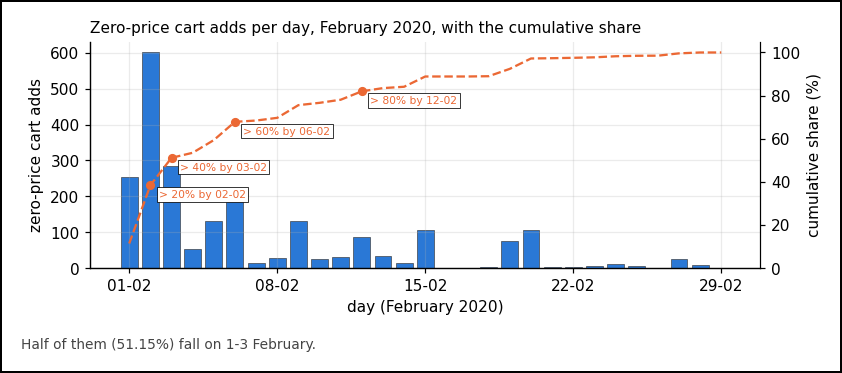

In [3]:
daily = z.groupby("event_date").size().reindex(pd.date_range("2020-02-01", "2020-02-29").strftime("%Y-%m-%d"), fill_value=0)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar(range(len(daily)), daily.values, color=BLUE, width=0.8, edgecolor="#333333", linewidth=0.4)
ax.set_xticks(range(0, len(daily), 7), [f"{d[8:]}-{d[5:7]}" for d in daily.index[::7]])
ax.set_xlabel("day (February 2020)"); ax.set_ylabel("zero-price cart adds")
ax2 = ax.twinx()
ax2.plot(range(len(daily)), daily.cumsum() / daily.sum() * 100, color=ORANGE, linestyle="--", linewidth=1.5, label="cumulative share")
cum = (daily.cumsum() / daily.sum() * 100).values
for t in (20, 40, 60, 80):
    i = int(np.argmax(cum >= t))
    ax2.plot(i, cum[i], "o", color=ORANGE, markersize=5)
    ax2.text(i + 0.4, cum[i] - 2, f"> {t}% by {daily.index[i][8:]}-{daily.index[i][5:7]}", fontsize=7, color=ORANGE, va="top", bbox=dict(facecolor="white", edgecolor="black", linewidth=0.5, pad=1.5))
ax2.set_ylim(0, 105); ax2.set_ylabel("cumulative share (%)"); ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.set_title("Zero-price cart adds per day, February 2020, with the cumulative share", fontsize=10, loc="left")
fig.text(0.01, 0.02, f"Half of them ({first3 / len(z):.2%}) fall on 1-3 February.", fontsize=9, color="#444444")
plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

**Observation:** zero-price cart adds rose from 154 in January to 2,227 in February. They are 2.06% of February's cart adds: small in absolute terms, but far above the 0.06–0.24% of October to January. The users making them only doubled (73 → 144), so each made far more: 15.47 per user, against 2.11 in January.

**Observation:** they are concentrated: 144 users in 189 sessions, the top 5 users made 31.30% of them, and 51.15% fall on 1–3 February. Every one has no brand (against 44.11% of other cart adds), 1,679 of their 1,872 products appear at a price above 0 somewhere in the data, and for only 1.35% did the same user also view that product at a price above 0 in February.

**Hypothesis:** two possible causes, which this data can't tell apart: a logging fault that sent some cart adds without price and brand, or a few unusual accounts adding many products in bulk without browsing them (e.g. staff or a reseller).

**Memo:**
- **Bottom line:** February's jump in zero-price cart adds comes from 144 users, half of it on 1–3 February, and its cause can't be determined from this data. They are 2.06% of February's cart adds, far above the 0.06–0.24% of earlier months.
- **Checks:** (1) data right? Probably not: points to logging or a few accounts: brand always missing, products normally priced, rarely viewed at a price. (2) calendar? No: a 14-fold jump in one month is far beyond any day-count or holiday effect. (3) mix or rate? Not applicable: it is a count from a few users. (4) where? 144 users, top 5 = 31.30%.
- **Not explained:** logging fault or bulk accounts. The store's engineers (was price/brand empty in the cart request?) or account records (who are these 144 users?) would settle it.

### Case 2 — The payer rate fell from November to December

**The question:** the payer rate (Module 8: the share of a month's active users who placed at least one order) fell from 8.54% in November to 6.82% in December. Mix or rate?

**Groups:** **new** users (first event in the data that month) and **returning** users (seen in an earlier month).

**3. Mix or rate?** and **4. Where is it?** The payer rate split by group:

In [4]:
act = query(con, "SELECT DISTINCT user_id, event_month FROM events_clean")
first = query(con, "SELECT user_id, MIN(event_month) AS first_month FROM events_clean GROUP BY user_id")
paid = query(con, "SELECT DISTINCT user_id, event_month FROM orders").assign(bought=1)
um = act.merge(first, on="user_id").merge(paid, on=["user_id", "event_month"], how="left").fillna({"bought": 0})
um["group"] = np.where(um["first_month"] == um["event_month"], "new", "returning")
seg = um.groupby(["event_month", "group"]).agg(users=("bought", "size"), buyers=("bought", "sum"))
seg["rate"] = seg["buyers"] / seg["users"] * 100

def split(a, b):
    sa, sb = seg.loc[a], seg.loc[b]
    wa, wb = sa["users"] / sa["users"].sum(), sb["users"] / sb["users"].sum()
    mix = (wb - wa) * (sa["rate"] + sb["rate"]) / 2
    rate = (wa + wb) / 2 * (sb["rate"] - sa["rate"])
    total = sb["buyers"].sum() / sb["users"].sum() * 100 - sa["buyers"].sum() / sa["users"].sum() * 100
    return wa, wb, mix, rate, total

def show_months(a, b):
    wa, wb, mix, rate, total = split(a, b)
    sa, sb = seg.loc[a], seg.loc[b]
    show(pd.DataFrame({"group": sa.index,
                       f"share of users {a} %": (wa * 100).map("{:.2f}".format).values, f"share of users {b} %": (wb * 100).map("{:.2f}".format).values,
                       f"payer rate {a} %": sa["rate"].map("{:.2f}".format).values, f"payer rate {b} %": sb["rate"].map("{:.2f}".format).values}))
    print()
    print(f"payer rate, all users: {sa['buyers'].sum() / sa['users'].sum() * 100:.2f}% -> {sb['buyers'].sum() / sb['users'].sum() * 100:.2f}%  (change {total:+.2f} points)")
    print(f"mix effect:  {mix.sum():+.2f} points  (" + ",  ".join(f"{g} {v:+.2f}" for g, v in mix.items()) + ")")
    print(f"rate effect: {rate.sum():+.2f} points  (" + ",  ".join(f"{g} {v:+.2f}" for g, v in rate.items()) + ")")
    print(f"check: {mix.sum():+.2f} + ({rate.sum():+.2f}) = {mix.sum() + rate.sum():+.2f} = the change")
    print()
    print("the calculation (shares as fractions, rates in %):")
    for g in sa.index:
        print(f"  mix, {g + ':':<11} (change in share) x (average rate) = ({wb[g]:.4f} - {wa[g]:.4f}) x ({sa.loc[g, 'rate']:.3f} + {sb.loc[g, 'rate']:.3f}) / 2"
              f" = {wb[g] - wa[g]:+.4f} x {(sa.loc[g, 'rate'] + sb.loc[g, 'rate']) / 2:.3f} = {mix[g]:+.2f}")
    for g in sa.index:
        print(f"  rate, {g + ':':<10} (average share) x (change in rate) = ({wa[g]:.4f} + {wb[g]:.4f}) / 2 x ({sb.loc[g, 'rate']:.3f} - {sa.loc[g, 'rate']:.3f})"
              f" = {(wa[g] + wb[g]) / 2:.4f} x {sb.loc[g, 'rate'] - sa.loc[g, 'rate']:+.3f} = {rate[g]:+.2f}")

show_months("2019-11", "2019-12")

group      share of users 2019-11 %  share of users 2019-12 %  payer rate 2019-11 %  payer rate 2019-12 %
new                           85.25                     81.08                  6.41                  4.72
returning                     14.75                     18.92                 20.84                 15.82

payer rate, all users: 8.54% -> 6.82%  (change -1.72 points)
mix effect:  +0.53 points  (new -0.23,  returning +0.76)
rate effect: -2.26 points  (new -1.41,  returning -0.85)
check: +0.53 + (-2.26) = -1.72 = the change

the calculation (shares as fractions, rates in %):
  mix, new:        (change in share) x (average rate) = (0.8108 - 0.8525) x (6.410 + 4.715) / 2 = -0.0417 x 5.563 = -0.23
  mix, returning:  (change in share) x (average rate) = (0.1892 - 0.1475) x (20.843 + 15.816) / 2 = +0.0417 x 18.329 = +0.76
  rate, new:       (average share) x (change in rate) = (0.8525 + 0.8108) / 2 x (4.715 - 6.410) = 0.8317 x -1.694 = -1.41
  rate, returning: (average share) x (cha

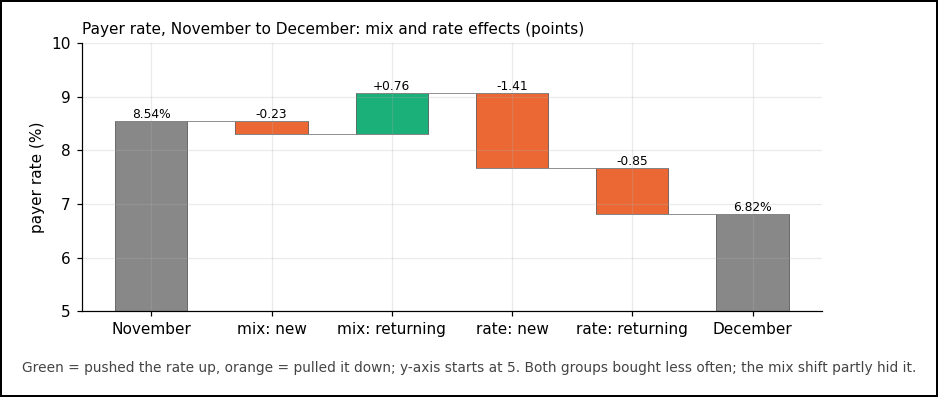

In [5]:
def rate_waterfall(a, b, a_name, b_name, note):
    wa, wb, mix, rate, total = split(a, b)
    start = seg.loc[a, "buyers"].sum() / seg.loc[a, "users"].sum() * 100
    steps = [("mix: new", mix["new"]), ("mix: returning", mix["returning"]), ("rate: new", rate["new"]), ("rate: returning", rate["returning"])]
    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    ax.bar(0, start, color=GREY, width=0.6, edgecolor="#333333", linewidth=0.4)
    ax.text(0, start, f"{start:.2f}%", ha="center", va="bottom", fontsize=8)
    level = start
    for i, (name, s) in enumerate(steps, start=1):
        ax.bar(i, s, bottom=level, color=AQUA if s >= 0 else ORANGE, width=0.6, edgecolor="#333333", linewidth=0.4)
        ax.plot([i - 1.3, i + 0.3], [level, level], color=GREY, linewidth=0.6)
        ax.text(i, max(level, level + s), f"{s:+.2f}", ha="center", va="bottom", fontsize=8)
        level += s
    ax.plot([len(steps) - 0.3, len(steps) + 1.3], [level, level], color=GREY, linewidth=0.6)
    ax.bar(len(steps) + 1, level, color=GREY, width=0.6, edgecolor="#333333", linewidth=0.4)
    ax.text(len(steps) + 1, level, f"{level:.2f}%", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(steps) + 2), [a_name] + [n for n, _ in steps] + [b_name])
    ax.set_ylim(5, 10); ax.set_ylabel("payer rate (%)")
    ax.set_title(f"Payer rate, {a_name} to {b_name}: mix and rate effects (points)", fontsize=10, loc="left")
    fig.text(0.01, 0.02, "Green = pushed the rate up, orange = pulled it down; y-axis starts at 5. " + note, fontsize=9, color="#444444")
    plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

rate_waterfall("2019-11", "2019-12", "November", "December", "Both groups bought less often; the mix shift partly hid it.")

**Observation:** the mix moved the payer rate *up* (+0.53 points): returning users, who buy far more often (20.84% vs. 6.41% in November), grew from 14.75% to 18.92% of users. (New users' share fell, a small pull down; returning users' share rose, a bigger push up.) The rates moved it down (−2.26): new users' payer rate fell from 6.41% to 4.72% (−1.41 points of the total) and returning users' from 20.84% to 15.82% (−0.85).

Both groups moved the same way as the total, so this is not a Simpson's paradox (where every group moves one way and the total the other).

**Hypothesis:** November's rates were lifted by Black Friday (Module 2), so December looks like a fall partly because November was unusual. Not tested here: it would need a comparison with an ordinary month, or with November–December of another year.

**Memo:**
- **Bottom line:** the payer rate fell because both new and returning users bought less often in December, possibly because November was lifted by Black Friday (not tested). The mix change pushed the rate up, hiding part of the fall.
- **Checks:** (1) data right? Yes: orders and buyers are counted the same way every month (Module 8). (2) calendar? Possibly: November holds Black Friday, a likely high point. (3) mix or rate? Rate: −2.26 points, with mix +0.53; part of the mix effect is the growing data window (more users count as returning each month). (4) where? In both groups, most in new users (−1.41 points).
- **Not explained:** whether this is a December slump or a November spike; 12 months of history, or November–December a year earlier, would settle it.

### Case 3 — "DAU dropped 8% on Tuesday" (simulated)

**The question:** daily active users (DAU) fell 8% on day 28, a Tuesday, against the Tuesday before. Why?

**The simulated data (labelled simulated; all numbers are a chosen example):** 28 days (day 1 = a Wednesday, day 28 = a Tuesday), on three platforms (web, Android, iOS). Two sources:
- **logged DAU,** from the event log;
- **backend DAU,** from the login server, a second source that the event log doesn't feed. It also records each user's app version.

**The planted cause (the known answer):** on day 28, a new iOS app version (2.0) is installed by 40% of iOS users, and it doesn't send events. Users are still active; their events just aren't logged.

**1. Is the data right?** and **2. Is it the calendar?** Logged vs. backend DAU on each Tuesday:

In [6]:
rng = np.random.default_rng(10)
days = pd.date_range("2020-03-04", periods=28)
base = {"web": 5000, "Android": 3000, "iOS": 2000}
weekday_factor = np.where(days.dayofweek == 5, 0.85, np.where(days.dayofweek == 6, 0.80, 1.0))
rows = []
for p, n in base.items():
    true_dau = np.round(n * weekday_factor * rng.normal(1, 0.015, len(days))).astype(int)
    v2_share = np.where(np.arange(len(days)) == len(days) - 1, 0.40, 0.0) if p == "iOS" else np.zeros(len(days))
    logged_v1 = np.round(true_dau * (1 - v2_share)).astype(int)
    for d, t, l1 in zip(days, true_dau, logged_v1):
        rows.append({"day": d, "platform": p, "backend": t, "logged": l1, "logged v2.0": 0, "backend v2.0": t - l1})
sim = pd.DataFrame(rows)
tot = sim.groupby("day")[["logged", "backend"]].sum()
tues = tot[tot.index.dayofweek == 1]
show(pd.DataFrame({"Tuesday": [f"day {(d - days[0]).days + 1}" for d in tues.index], "logged DAU": tues["logged"].map("{:,}".format).values,
                   "backend DAU": tues["backend"].map("{:,}".format).values,
                   "logged ÷ backend %": (tues["logged"] / tues["backend"] * 100).map("{:.2f}".format).values}))
last, prev = tues.index[-1], tues.index[-2]
print()
print(f"logged DAU, day 28 vs. day 21 (both Tuesdays): {tot.loc[last, 'logged'] / tot.loc[prev, 'logged'] - 1:+.2%};  backend DAU: {tot.loc[last, 'backend'] / tot.loc[prev, 'backend'] - 1:+.2%}")

Tuesday  logged DAU  backend DAU  logged ÷ backend %
day 7        10,062       10,062              100.00
day 14        9,981        9,981              100.00
day 21        9,951        9,951              100.00
day 28        9,166        9,958               92.05

logged DAU, day 28 vs. day 21 (both Tuesdays): -7.89%;  backend DAU: +0.07%


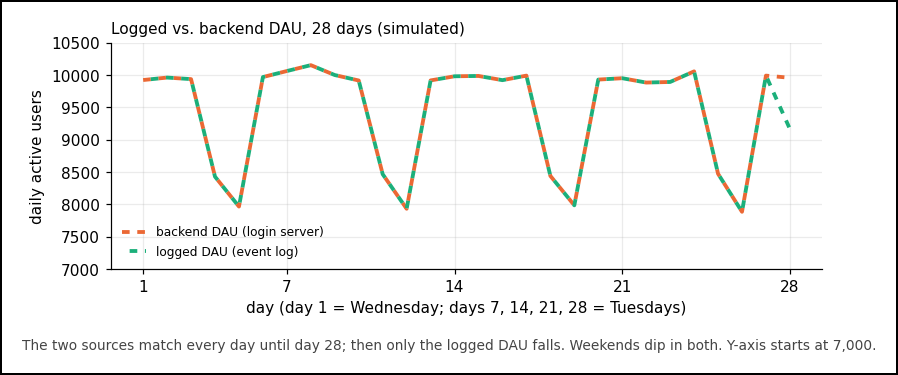

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
x = np.arange(1, len(tot) + 1)
ax.plot(x, tot["backend"], color=ORANGE, linewidth=2.5, linestyle=(0, (2, 2)), label="backend DAU (login server)")
ax.plot(x, tot["logged"], color=AQUA, linewidth=2.5, linestyle=(2, (2, 2)), label="logged DAU (event log)")
ax.set_xticks([1, 7, 14, 21, 28]); ax.set_xlabel("day (day 1 = Wednesday; days 7, 14, 21, 28 = Tuesdays)")
ax.set_ylim(7000, 10500); ax.set_ylabel("daily active users")
ax.legend(frameon=False, fontsize=8, loc="lower left")
ax.set_title("Logged vs. backend DAU, 28 days (simulated)", fontsize=10, loc="left")
fig.text(0.01, 0.02, "The two sources match every day until day 28; then only the logged DAU falls. Weekends dip in both. Y-axis starts at 7,000.", fontsize=9, color="#444444")
plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

**4. Where is it?** Logged and backend DAU on the last two Tuesdays (days 21 and 28), by platform:

In [8]:
w = sim[sim["day"].isin([prev, last])].pivot_table(index="platform", columns="day", values=["logged", "backend"], aggfunc="sum").reindex(list(base))
show(pd.DataFrame({"platform": w.index,
                   "logged, day 21": w[("logged", prev)].map("{:,}".format).values, "logged, day 28": w[("logged", last)].map("{:,}".format).values,
                   "logged change %": ((w[("logged", last)] / w[("logged", prev)] - 1) * 100).map("{:+.2f}".format).values,
                   "backend, day 21": w[("backend", prev)].map("{:,}".format).values, "backend, day 28": w[("backend", last)].map("{:,}".format).values,
                   "backend change %": ((w[("backend", last)] / w[("backend", prev)] - 1) * 100).map("{:+.2f}".format).values}))
ios_last = sim[(sim["day"] == last) & (sim["platform"] == "iOS")].iloc[0]
print()
print(f"iOS on day 28, by app version: older versions logged {ios_last['logged']:,} of {ios_last['backend'] - ios_last['backend v2.0']:,} active;  version 2.0 logged {ios_last['logged v2.0']} of {ios_last['backend v2.0']:,} active ({ios_last['backend v2.0']:,} = iOS backend {ios_last['backend']:,} - iOS logged {ios_last['logged']:,})")

platform  logged, day 21  logged, day 28  logged change %  backend, day 21  backend, day 28  backend change %
web                4,926           5,076            +3.05            4,926            5,076             +3.05
Android            3,027           2,901            -4.16            3,027            2,901             -4.16
iOS                1,998           1,189           -40.49            1,998            1,981             -0.85

iOS on day 28, by app version: older versions logged 1,189 of 1,189 active;  version 2.0 logged 0 of 792 active (792 = iOS backend 1,981 - iOS logged 1,189)


**Memo:**
- **Bottom line:** the drop is a logging bug, not lost users. iOS app version 2.0 sends no events, so its users vanish from the logged DAU while the login server still sees them.
- **Checks:** (1) data right? No: backend DAU is flat (+0.07%) while logged DAU fell 7.89%; logged ÷ backend fell from 100.00% to 92.05%. (2) calendar? No: earlier Tuesdays are level. (3) mix or rate? Not needed: step 1 already found a logging fault. (4) where? Only on iOS do the two sources disagree (logged −40.49%, backend −0.85%; on web and Android they move together), and only for version 2.0 (0 events logged for 792 active users).
- **Not explained:** nothing left. Next step: fix version 2.0's event sending, and mark the gap in every dashboard that uses logged DAU.

## Exercises

### Exercise 1 — Revenue fell 4.06% from January to February

**The question:** monthly revenue fell 4.06% from January to February (Module 8). Write the diagnosis memo.

**1. Is the data right?** and **2. Is it the calendar?**

In [9]:
rev = query(con, "SELECT event_month, SUM(revenue) AS revenue, COUNT(*) AS orders FROM orders WHERE event_month IN ('2020-01', '2020-02') GROUP BY event_month").set_index("event_month")
rev["days"] = [31, 29]
rev["per day"] = rev["revenue"] / rev["days"]
show(pd.DataFrame({"month": rev.index, "revenue": rev["revenue"].map("{:,.2f}".format).values, "orders": rev["orders"].map("{:,}".format).values,
                   "days": rev["days"].values, "revenue per day": rev["per day"].map("{:,.2f}".format).values,
                   "orders per day": (rev["orders"] / rev["days"]).map("{:.2f}".format).values,
                   "revenue per order": (rev["revenue"] / rev["orders"]).map("{:.2f}".format).values}))
print()
print(f"revenue: {rev['revenue'].iloc[1] / rev['revenue'].iloc[0] - 1:+.2%};  expected from the day count alone: 29 / 31 - 1 = {29 / 31 - 1:+.2%}")
print(f"per day: revenue {rev['per day'].iloc[1] / rev['per day'].iloc[0] - 1:+.2%},  orders {(rev['orders'].iloc[1] / 29) / (rev['orders'].iloc[0] / 31) - 1:+.2%},  revenue per order {(rev['revenue'].iloc[1] / rev['orders'].iloc[1]) / (rev['revenue'].iloc[0] / rev['orders'].iloc[0]) - 1:+.2%}")

month       revenue  orders  days  revenue per day  orders per day  revenue per order
2020-01  127,663.13   3,268    31         4,118.17          105.42              39.06
2020-02  122,475.70   2,961    29         4,223.30          102.10              41.36

revenue: -4.06%;  expected from the day count alone: 29 / 31 - 1 = -6.45%
per day: revenue +2.55%,  orders -3.15%,  revenue per order +5.88%


**Memo:**
- **Bottom line:** it's the calendar. February has 29 days and January 31; per day, revenue *rose* 2.55%.
- **Checks:** (1) data right? Yes: orders and revenue are built the same way in both months (Module 8). (2) calendar? Yes: the day count alone predicts −6.45%, more than the actual −4.06%. (3) and (4): not needed for a fall the calendar explains.
- **Not explained:** per day, orders fell 3.15% while revenue per order rose 5.88%; why buyers placed fewer but bigger orders isn't visible here.

### Exercise 2 — The payer rate fell from January to February

**The question:** the payer rate fell from 6.83% to 6.45% (January → February). Mix or rate, and where?

**3. Mix or rate?** and **4. Where is it?** The payer rate split by group:

In [10]:
show_months("2020-01", "2020-02")
print()
print(f"calendar check, equal 29-day windows: 1-29 January {metric(con, 'payer_rate', '2020-01-01', '2020-01-29') * 100:.2f}%,  February {metric(con, 'payer_rate', '2020-02-01', '2020-02-29') * 100:.2f}%")

group      share of users 2020-01 %  share of users 2020-02 %  payer rate 2020-01 %  payer rate 2020-02 %
new                           80.35                     75.97                  4.43                  4.13
returning                     19.65                     24.03                 16.68                 13.79

payer rate, all users: 6.83% -> 6.45%  (change -0.38 points)
mix effect:  +0.48 points  (new -0.19,  returning +0.67)
rate effect: -0.86 points  (new -0.23,  returning -0.63)
check: +0.48 + (-0.86) = -0.38 = the change

the calculation (shares as fractions, rates in %):
  mix, new:        (change in share) x (average rate) = (0.7597 - 0.8035) x (4.426 + 4.130) / 2 = -0.0438 x 4.278 = -0.19
  mix, returning:  (change in share) x (average rate) = (0.2403 - 0.1965) x (16.679 + 13.786) / 2 = +0.0438 x 15.233 = +0.67
  rate, new:       (average share) x (change in rate) = (0.8035 + 0.7597) / 2 x (4.130 - 4.426) = 0.7816 x -0.296 = -0.23
  rate, returning: (average share) x (cha

calendar check, equal 29-day windows: 1-29 January 6.93%,  February 6.45%


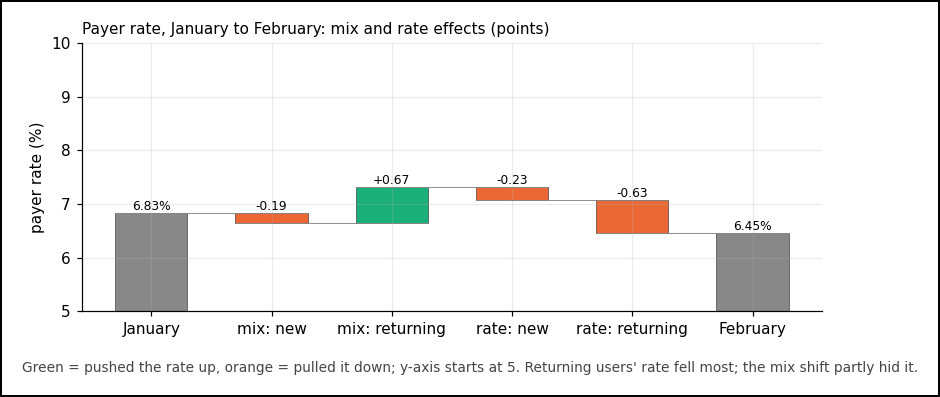

In [11]:
rate_waterfall("2020-01", "2020-02", "January", "February", "Returning users' rate fell most; the mix shift partly hid it.")

**Memo:**
- **Bottom line:** returning users bought less often (16.68% → 13.79%); a growing share of returning users hid part of it.
- **Checks:** (1) data right? Yes: same definitions as every month. (2) calendar? No: on equal 29-day windows, January's payer rate is 6.93%, so the fall isn't the shorter month. (3) mix or rate? Rate: −0.86 points, with mix +0.48 (part of it the growing data window). (4) where? Mostly returning users (−0.63 of the −0.86).
- **Not explained:** why returning users bought less: not visible in this data.

## Key takeaways

- **Conclusion:** diagnose in a fixed order: is the data right, is it the calendar, mix or rate, where, and what can't be explained.
- **Observation:** February's zero-price cart adds come from 144 users, half on 1–3 February, always without a brand; the cause can't be settled from this data.
- **Observation:** November → December, the payer rate fell 1.72 points: mix +0.53, rate −2.26. Both groups bought less often, and the mix shift hid part of the fall.
- **Observation (simulated):** an 8% DAU drop with a flat second source was a logging bug, found at the first check.
- **Observation (exercises):** January → February, the calendar explains the revenue fall (per day +2.55%), and returning users drove the payer-rate fall (−0.63 of −0.86 points).
- **Conclusion:** write the answer bottom line first, and say plainly what the data can't explain.